<a href="https://colab.research.google.com/github/KiranmayiBandaru/credit-scoring-loan-risk-analysis/blob/main/credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Exploratory Data Analysis  -  EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/KiranmayiBandaru/credit-scoring-loan-risk-analysis/refs/heads/main/customer_dataset.csv')
print(df.shape) #tuples and columns

print(df.head())


(5451, 13)
   id  person_age  person_income person_home_ownership  person_emp_length  \
0   0          37          35000                  RENT                0.0   
1   1          22          56000                   OWN                6.0   
2   2          29          28800                   OWN                8.0   
3   3          30          70000                  RENT               14.0   
4   4          22          60000                  RENT                2.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0   EDUCATION          B       6000          11.49                 0.17   
1     MEDICAL          C       4000          13.35                 0.07   
2    PERSONAL          A       6000           8.90                 0.21   
3     VENTURE          B      12000          11.11                 0.17   
4     MEDICAL          A       6000           6.92                 0.10   

  cb_person_default_on_file  cb_person_cred_hist_length  loan_status  
0   

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          5451 non-null   int64  
 1   person_age                  5451 non-null   int64  
 2   person_income               5451 non-null   int64  
 3   person_home_ownership       5451 non-null   object 
 4   person_emp_length           5451 non-null   float64
 5   loan_intent                 5451 non-null   object 
 6   loan_grade                  5451 non-null   object 
 7   loan_amnt                   5451 non-null   int64  
 8   loan_int_rate               5451 non-null   float64
 9   loan_percent_income         5451 non-null   float64
 10  cb_person_default_on_file   5451 non-null   object 
 11  cb_person_cred_hist_length  5451 non-null   int64  
 12  loan_status                 5451 non-null   int64  
dtypes: float64(3), int64(6), object(4

In [3]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,5451.00000,5451.000000,5.451000e+03,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000
mean,2725.00000,27.476977,6.453183e+04,4.667584,9254.338653,10.669551,0.158191,5.750504,0.146395
std,1573.71249,5.864273,3.669211e+04,3.889993,5600.892743,3.052436,0.091173,3.949560,0.353534
min,0.00000,21.000000,9.600000e+03,0.000000,1000.000000,5.420000,0.010000,2.000000,0.000000
25%,1362.50000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,2725.00000,26.000000,6.000000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,4087.50000,30.000000,7.800000e+04,7.000000,12000.000000,12.890000,0.210000,8.000000,0.000000
max,5450.00000,84.000000,1.200000e+06,26.000000,35000.000000,22.110000,0.510000,30.000000,1.000000


Here we can see unsual or interesting values :
  
for example , when the max age_of_customer = 144.
mean vs meadian is 50% , if they are different they are skewed.
large range — if min is 0 and max is 6000000, that's a huge range which affects your model.


person_age has a min of 21 and max of 84. That seems reasonable.
But look at person_income — min is 9,600 and max is 1,200,000. That's a huge range. Someone earning 9,600 vs someone earning 12,00,000 — that's extreme.
Also look at person_emp_length — min is 0 and max is 26 years. Someone with 0 years employment applying for a loan is unusual.
These are called outliers — extreme values that can confuse your model.


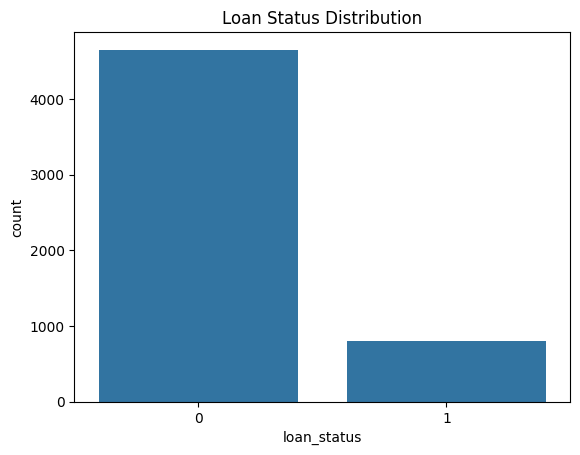

In [4]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

Here, count of the non-defaulters is extremely higher than the defaulters , hence it gets difficult for the algorithm to identify features of the defaulters class.

Hence , we see "class imbalance".


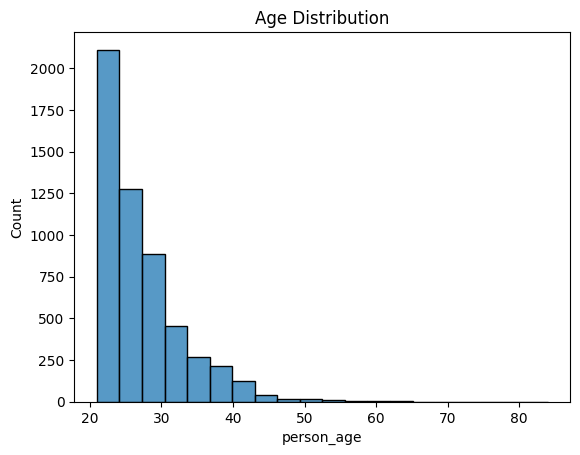

In [5]:
sns.histplot(df['person_age'] , bins=20)
plt.title('Age Distribution')
plt.show()

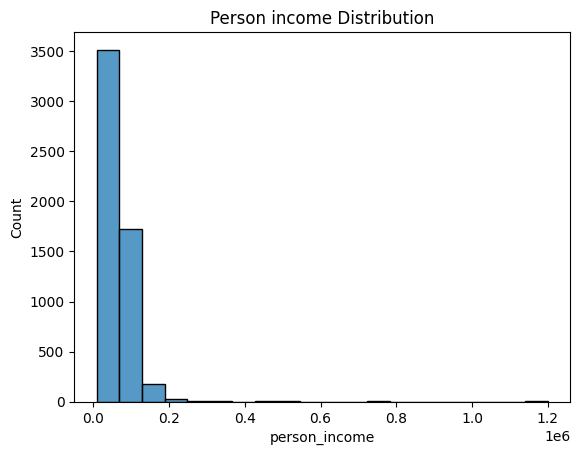

In [6]:
sns.histplot(df['person_income'], bins=20)
plt.title('Person income Distribution')
plt.show()

That's called a right skewed distribution — most people have low income but a few people have very high income (remember that max of 12,00,000 we saw earlier). Those few high income people create that long tail on the right.

This is an outlier problem.

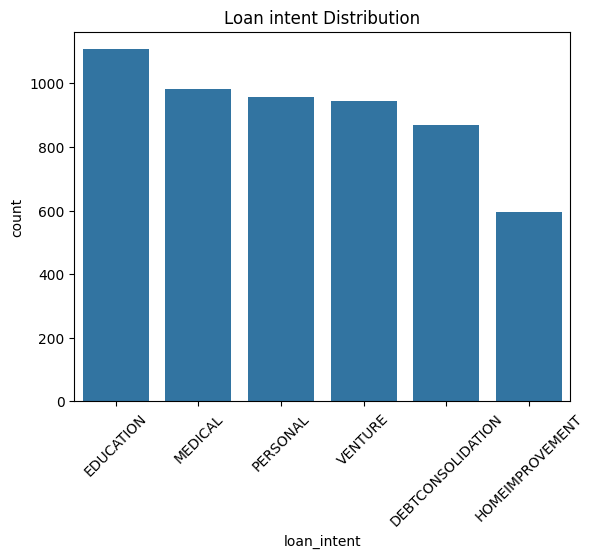

In [7]:
sns.countplot(x='loan_intent', data=df)
plt.xticks(rotation=45)
plt.title('Loan intent Distribution')
plt.show()

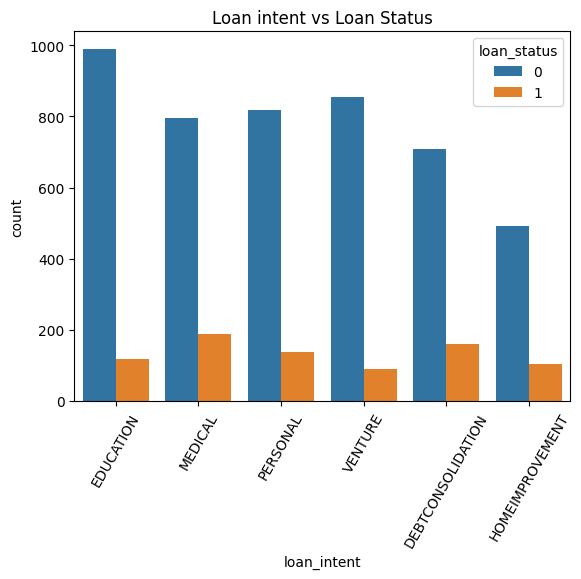

In [8]:
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.xticks(rotation = 60)
plt.title('Loan intent vs Loan Status')
plt.show()

no single loan intent is dramatically riskier than others. That's a valid EDA insight.

  -> No missing values

  -> 4 categorical columns need encoding

  -> Class imbalance confirmed — SMOTE needed

  -> Most applicants are aged 20-30

  -> Income is right skewed — outliers exist

  -> Loan intent fairly evenly distributed
  
  -> No single intent dramatically causes default

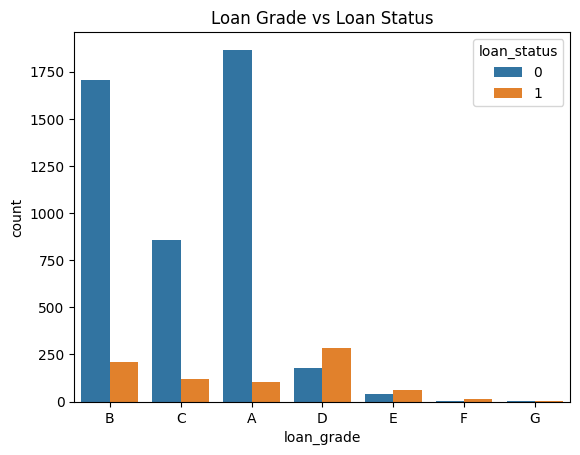

In [9]:
sns.countplot(x='loan_grade', hue="loan_status", data=df)
plt.xticks(rotation=0)
plt.title('Loan Grade vs Loan Status')
plt.show()

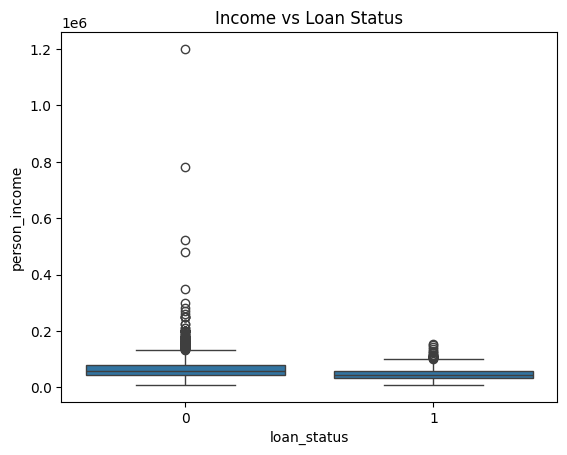

In [10]:
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Income vs Loan Status')
plt.show()

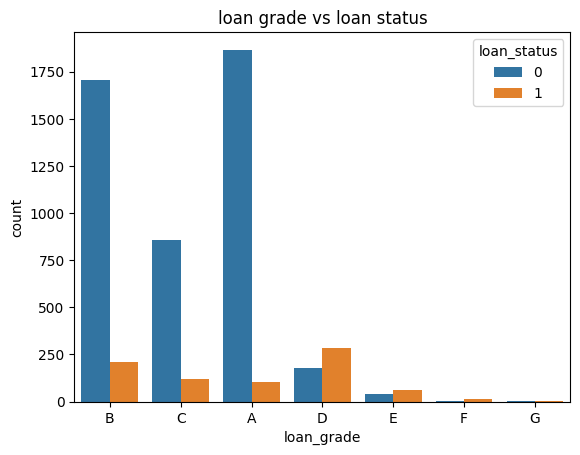

In [11]:
sns.countplot(x='loan_grade', hue='loan_status', data=df)
plt.title('loan grade vs loan status')
plt.show()

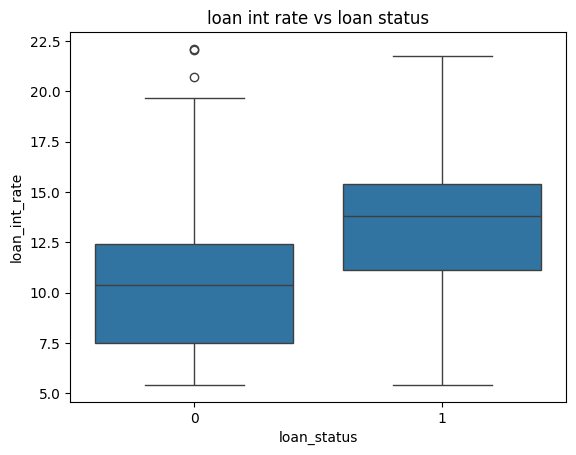

In [12]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)
plt.title('loan int rate vs loan status')
plt.show()

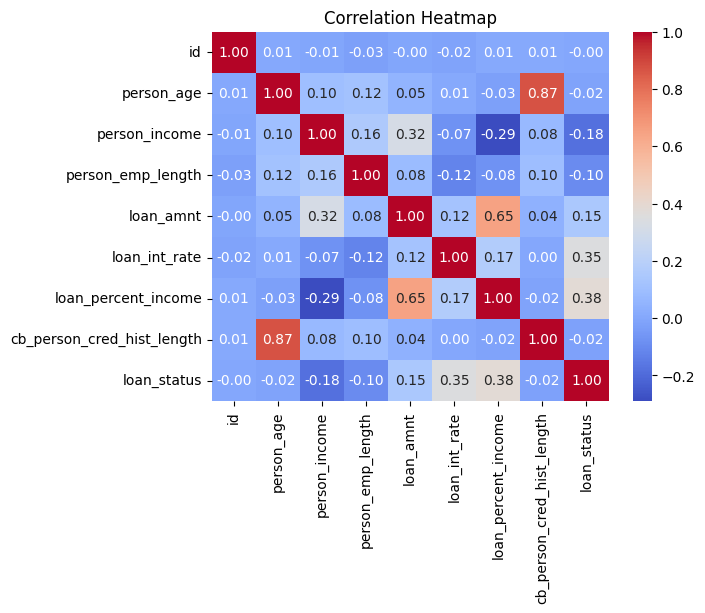

In [13]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

from the correltion matrix , we found:

Higher loan_int_rate → more likely to default

Higher loan_percent_income → more likely to default


# Preprocessing


Dropped the unnecessary column. the feature which has no influence/ not useful for predicting loan default.


In [14]:
df = df.drop(columns = ['id'])
print(df.shape)

(5451, 12)


Encode categorical columns.

There are two types of ordered categories and unordered categories.

Ordered categories have ranking.here, the loan_grade- A< B< C< D< E are its values.
Unordered categories - have mutliple possible values . here those columns are : cb_person_default_on_file — Y, N ; person_home_ownership — RENT, OWN, MORTGAGE, OTHER ;
loan_intent — EDUCATION, MEDICAL, PERSONAL etc.

lets, encode the values into a numberical value for ordered category

encoding techniques are two types - **Label encoding** and  **One Hot Encoding.**

Label Encoding - used for ordered categories which converts the values into numbers - 1,2,3,..

One Hot Encoding - used for unordered categories which creates separate column for each categories.

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['loan_grade'] = le.fit_transform(df['loan_grade'])
print(df['loan_grade'].unique())

[1 2 0 3 4 5 6]


Now let's work on the unordered catgorical columns using one hot encoding.

In [16]:
df = pd.get_dummies(df, columns = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file'])
print(df.shape)
print(df.columns)

(5451, 21)
Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'loan_status',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y'],
      dtype='object')


Before we perform SMOTE, let's do "train-test split". The columns are split into features (X) and target variable (Y).

Y(target variable) - loan status
X - rest other features



In [17]:
X = df.drop(columns = ['loan_status'])
y = df['loan_status']

print(X.shape)
print(y.shape)

(5451, 20)
(5451,)


Now Actual train test split


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(4360, 20)
(4360,)
(1091, 20)
(1091,)


**SMOTE - Synthetic Minority Oversampling Method**
This method is used when the dataset has the class imbalance. Here, the majority of the tuples are classified into non-defaulted customer. Hence the machine gets very less data to train upon the defaulters.

SMOTE is applied only on training data, never on test data.

Test data represents real world unseen data. If you apply SMOTE on test data you're artificially creating fake data points there — which defeats the purpose of testing on real data.
SMOTE only goes on training data so the model learns from balanced data, but gets tested on real world distribution.

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train_resampled.value_counts())

loan_status
0    3722
1    3722
Name: count, dtype: int64


**Feature Scaling :** the attribute data-type is same but the value range varies for both the columns drastically.
for example : age and salary columns

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

print("Scaling Done")
print("X_train shape: " , X_train_resampled.shape)
print("X_test shape: ", X_test.shape)

Scaling Done
X_train shape:  (7444, 20)
X_test shape:  (1091, 20)


**fit** — the scaler learns the min, max, mean of the training data
**transform** — it applies that scaling

So fit_transform on training data = learn the scale AND apply it.
transform on test data = apply the same scale learned from training — without learning again.

Why not fit on test data too? Because test data represents real world unseen data. If you learn scaling from test data, you're leaking information about the future into your model. That's called data leakage — a big mistake in ML.

# Model Building

WE are using 3 algorithms to build the model. Logistic Regression , Random Forest and XGBoost .

Logistic Regression is your baseline model — the simplest one.

You train it first to set a benchmark. Then Random Forest and XGBoost should do better than this baseline.

In [21]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression predictions done.")

Logistic Regression predictions done.


In [22]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression accuracy : ", lr_accuracy)

Logistic Regression accuracy :  0.9019248395967002


 **Random Forest**

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

rf__accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest accuracy : ", rf__accuracy)

Random Forest accuracy :  0.9340054995417049


**XGBoost**


In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9376718606782768


# Evaluation

The specific problem is — if your model just predicts everyone as non-defaulter, it still gets 85% accuracy because 85% of your dataset IS non-defaulters.

So high accuracy doesn't mean the model is actually catching defaulters — which is the whole point of your project.
That's why we need metrics that specifically tell us how well the model identifies defaulters.

The 4 metrics you'll use:

Precision — of all people predicted as defaulters, how many actually were?

Recall — of all actual defaulters, how many did the model catch?

F1 Score — balance between precision and recall

AUC-ROC — overall ability to separate the two classes

In bank's perspective:

Missing a defaulter — bank gives loan to someone who won't repay → bank loses money

Wrongly flagging a good customer — bank rejects someone who would have repaid → bank misses business but loses nothing

Losing actual money is worse than missing a business opportunity.
So Recall is more important — you want to catch as many defaulters as possible even if you occasionally reject a good customer.

This is called the cost of false negatives in ML.

In [25]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest :")
print(classification_report(y_test, y_pred_rf))

print("\nXGBoost :")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       931
           1       0.72      0.55      0.62       160

    accuracy                           0.90      1091
   macro avg       0.82      0.76      0.78      1091
weighted avg       0.89      0.90      0.90      1091


Random Forest :
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       931
           1       0.85      0.66      0.75       160

    accuracy                           0.93      1091
   macro avg       0.90      0.82      0.85      1091
weighted avg       0.93      0.93      0.93      1091


XGBoost :
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       931
           1       0.87      0.68      0.76       160

    accuracy                           0.94      1091
   macro avg       0.91      0.83      0.86      1091
weighted avg       0.94  

let's plot the AUC-ROC curve for all 3 models::

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve

models = {'Logistic Regression': y_pred_lr,
          'Random Forest': y_pred_rf,
          'XGBoost': y_pred_xgb}

for name, preds in models.items():
    auc = roc_auc_score(y_test, preds)
    print(f"{name} AUC-ROC: {auc:.4f}")

Logistic Regression AUC-ROC: 0.7562
Random Forest AUC-ROC: 0.8216
XGBoost AUC-ROC: 0.8289


AUC-ROC of 0.829 means your model has good discriminating ability between defaulters and non-defaulters.

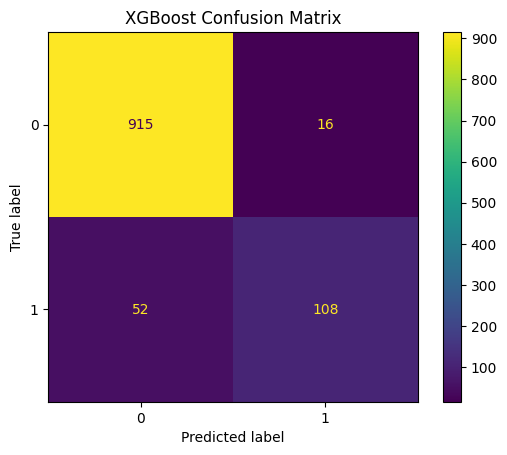

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('XGBoost Confusion Matrix')
plt.show()

SHAP - SHapley Additive exPlanations

XGBoost model predicts whether someone will default. But it doesn't tell you why. It's like a black box — input goes in, prediction comes out, no explanation.
SHAP opens that black box.
For every single prediction, SHAP tells you:

Which features pushed the prediction toward default
Which features pushed it away from default
How much each feature contributed.

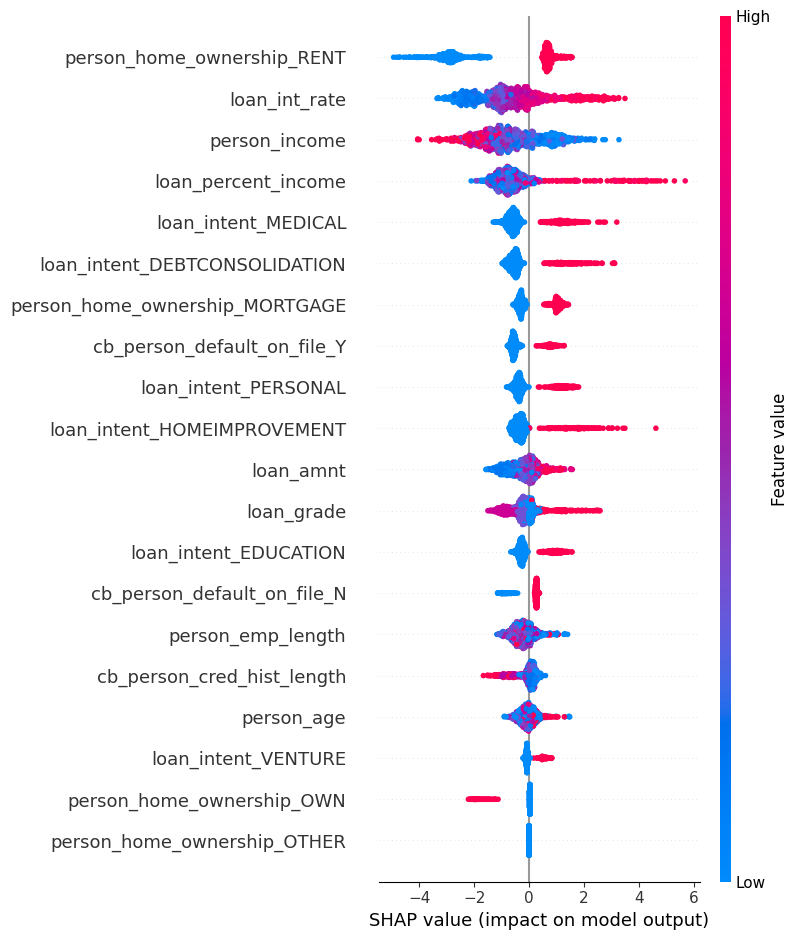

In [28]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=df.drop(columns=['loan_status']).columns)